In [72]:
import pandas as pd
df=pd.read_csv('data/Reviews.csv')
df.shape

(568454, 10)

In [73]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


To see the whole review

In [74]:
print(df["Text"][1])

Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor intended to represent the product as "Jumbo".


In [75]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


In [76]:
df["Score"].value_counts()

Score
5    363122
4     80655
1     52268
3     42640
2     29769
Name: count, dtype: int64

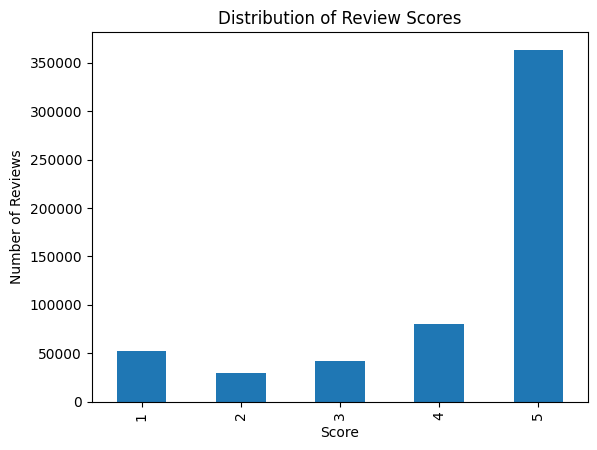

In [77]:
import matplotlib.pyplot as plt
df["Score"].value_counts().sort_index().plot(kind="bar")
plt.title("Distribution of Review Scores")
plt.xlabel("Score")
plt.ylabel("Number of Reviews")
plt.show()

In [78]:
df["Text"].str.len().describe()

count    568454.000000
mean        436.222083
std         445.339741
min          12.000000
25%         179.000000
50%         302.000000
75%         527.000000
max       21409.000000
Name: Text, dtype: float64

In [79]:
df["Text_len"]=df["Text"].str.len()
print(df.groupby("Score")["Text_len"].mean())

Score
1    478.082364
2    490.655010
3    520.319841
4    496.603273
5    402.447373
Name: Text_len, dtype: float64


In [80]:
import re
def clean_text(text):
    text=text.lower()
    text=re.sub(r'[^a-z0-9\s]',' ',text)
    text=" ".join(text.split())
    return text

In [81]:
result= clean_text(df["Text"][1])
print(result)

product arrived labeled as jumbo salted peanuts the peanuts were actually small sized unsalted not sure if this was an error or if the vendor intended to represent the product as jumbo


"random" sampling means you get different rows every time you run it.  random_state is a seed that makes randomness reproducible. With the same seed, .sample() picks the exact same 10,000 rows every single time you run it.

Imagine Monday you run your code and find a weird bug on a specific review. Tuesday you come back to fix it — but without random_state, .sample() grabbed a completely different 10,000 rows. That buggy review is gone. You can't reproduce the bug. You're chasing a ghost.
With random_state=42, you get the identical rows every time. Same data, same results, every run. So when something breaks, you can actually find it again and fix it. That's reproducibility 

In [82]:
sample_df=df.sample(10000,random_state=42)
sample_df.shape

(10000, 11)

In [83]:
sample_df["clean_text"]=sample_df["Text"].apply(clean_text)

In [84]:
sample_df[['Text','clean_text']].head()

,Text,clean_text
165256,Having tried a couple of other brands of glute...,having tried a couple of other brands of glute...
231465,My cat loves these treats. If ever I can't fin...,my cat loves these treats if ever i can t find...
427827,A little less than I expected. It tends to ha...,a little less than i expected it tends to have...
433954,"First there was Frosted Mini-Wheats, in origin...",first there was frosted mini wheats in origina...
70260,and I want to congratulate the graphic artist ...,and i want to congratulate the graphic artist ...


AspectIQ:
keyword matching

In [85]:
aspect_keyword={
    'packaging':['box','package','carton','container','wrapping','seal','bag','cardboard'],
    'delivery':['arrived','shipping','delivery','shipped','package arrived','courier'],
    'taste':['tastes','flavor','sweet','salty','sour','bitter','delicious','yummy','disgusting'],
    'price':['price','cost','expensive','cheap','worth','overpriced','affordable']
}

In [86]:
def detect_aspects(text):
    found_aspects=[]  # empty list to collect results
    for aspect, keywords in aspect_keyword.items():    # loop each aspect + its keyword list
        for keyword in keywords:  # loop each keyword in that list
            if keyword in text:   # check: is keyword in the text?
                found_aspects.append(aspect)  # add the aspect name
                break    # stop checking this aspect, move to next
    return found_aspects

In [87]:
detect_aspects("the box was crushed but it tastes great")



['packaging', 'taste']

test the aspect detector

In [88]:
print(detect_aspects("the service guy was sweet"))
print(detect_aspects("absolutely loved this product"))
print(detect_aspects("the carton was totally smashed"))

['taste']
[]
['packaging']


In [89]:
sample_df['aspects']=sample_df["clean_text"].apply(detect_aspects)


In [90]:
sample_df[["clean_text","aspects"]].head(10)

,clean_text,aspects
165256,having tried a couple of other brands of glute...,[taste]
231465,my cat loves these treats if ever i can t find...,"[taste, price]"
427827,a little less than i expected it tends to have...,[]
433954,first there was frosted mini wheats in origina...,[taste]
70260,and i want to congratulate the graphic artist ...,"[packaging, taste]"
49866,please add more pineapple flavor to your packa...,"[packaging, taste]"
551047,i absolutely love yorkshire tea and am so glad...,[]
18983,i have such a hard time finding loose tea loca...,[delivery]
138968,previously i ve attempted a recipe with white ...,[taste]
36352,i make pancakes or waffles every saturday morn...,[price]


In [91]:
(sample_df["aspects"].apply(len)==0).sum()

np.int64(3154)

 sample_df[mask] is already filtered down to only the empty-aspect rows.
So now the question is: WHY are those rows empty? To answer that, we don't look at the empty aspects column (it's just [] for all of them — tells us nothing). We look at the review text of those empty rows to see what they're actually about.

In [92]:
mask = sample_df['aspects'].apply(len) == 0

In [93]:
sample_df[mask]["clean_text"].head(10)

427827    a little less than i expected it tends to have...
551047    i absolutely love yorkshire tea and am so glad...
193068    in the uk this is one of the most popular choc...
34321     simply awful this product should be taken off ...
120857    satin ice is the best tasting fondant i can fi...
368061    i bought this for my 73 year old dad he had se...
568076    unbeatable little tool for making shredded gre...
326269    i had a salad in a restaurant for lunch and we...
32043     i was so happy to see this deal i recently hav...
437652    very hot but smooth great consistancy for use ...
Name: clean_text, dtype: object

In [94]:
pip install sentence-transformers

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [95]:
import torch
print(torch.__version__)

2.12.0+cpu


In [96]:
from sentence_transformers import SentenceTransformer
model=SentenceTransformer("all-MiniLM-L6-v2")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 4243.29it/s]


In [97]:
embedding=model.encode("this foundant tastes amazing")
print(embedding.shape)
print(embedding[:10])

(384,)
[-0.06534849 -0.07298446 -0.0300092   0.03572566  0.00144141  0.02544613
  0.04022605  0.04849375 -0.03201017 -0.00882235]


Running Cosine_Similarity

In [98]:
from sentence_transformers import util
review=model.encode("this foundant tastes amazing")
taste_aspect=model.encode("the flavor of the food")
packaging=model.encode("the box arrived crushed")

sim_taste=util.cos_sim(review,taste_aspect)
sim_packaging=util.cos_sim(review,packaging)

print("Review vs Taste:",sim_taste)
print("Review vs Packaging:",sim_packaging)

Review vs Taste: tensor([[0.5065]])
Review vs Packaging: tensor([[0.1338]])


In [99]:
aspect_descriptions = {
    'packaging': 'the box, packaging, container, carton, wrapper, how the product was packed, crushed, damaged, broken, torn, leaking',
    'delivery':  'shipping time, delivery speed, arrived late, shipped, courier, how long it took to arrive, delayed, wrong item delivered',
    'taste':     'how the product tastes, flavor, delicious, disgusting, sweet, salty, sour, bitter, yummy, bland, tastes like, flavor profile',
    'price':     'price, cost, expensive, cheap, affordable, overpriced, value for money, worth the price, too costly'
}

In [100]:
aspect_embeddings=model.encode(list(aspect_descriptions.values()))
print(aspect_embeddings.shape)

(4, 384)


In [101]:
def detect_aspects_batch(review_embedding, threshold=0.3):
    found_aspects = []
    for i, aspect in enumerate(aspect_descriptions.keys()):
        similarity = util.cos_sim(review_embedding, aspect_embeddings[i])
        if similarity > threshold:
            found_aspects.append(aspect)
    return found_aspects

In [102]:
emb1 = model.encode("the box was crushed but it tastes great")
emb2 = model.encode("the service guy was sweet")
emb3 = model.encode("the carton was totally smashed")

print(detect_aspects_batch(emb1))
print(detect_aspects_batch(emb2))
print(detect_aspects_batch(emb3))

['packaging', 'taste']
[]
['packaging']


In [103]:
#step 1 : encode all 10k reviews at once
review_embeddings= model.encode(sample_df['clean_text'].tolist(),batch_size=64,show_progress_bar=True)

#step2 : apply detection
sample_df['embed_aspects']=[detect_aspects_batch(emb) for emb in review_embeddings]

Batches: 100%|██████████| 157/157 [07:46<00:00,  2.97s/it]


In [104]:
sample_df[['clean_text','aspects','embed_aspects']].head(10)

,clean_text,aspects,embed_aspects
165256,having tried a couple of other brands of glute...,[taste],[]
231465,my cat loves these treats if ever i can t find...,"[taste, price]",[]
427827,a little less than i expected it tends to have...,[],[taste]
433954,first there was frosted mini wheats in origina...,[taste],[taste]
70260,and i want to congratulate the graphic artist ...,"[packaging, taste]","[packaging, taste]"
49866,please add more pineapple flavor to your packa...,"[packaging, taste]",[taste]
551047,i absolutely love yorkshire tea and am so glad...,[],[]
18983,i have such a hard time finding loose tea loca...,[delivery],[]
138968,previously i ve attempted a recipe with white ...,[taste],[]
36352,i make pancakes or waffles every saturday morn...,[price],[]


In [105]:
print(sample_df['clean_text'][231465])

my cat loves these treats if ever i can t find her in the house i just pop the top and she bolts out of wherever she was hiding to come get a treat she doesn t like crunchy treats much so these are perfect for her i ve given her all three flavors and she seems to like them all equally they do tend to dry out by the time i near the end of the bottle however the flip top lid is very handy very nice inexpensive kitty treats i have yet to meet a cat that doesn t just love these


In [106]:
#pick row 231465 - keywords said [taste,price], embeddings said []
review_text=sample_df["clean_text"][231465]
print(review_text)
print()

review_emb=model.encode(review_text)
for i, aspect in enumerate(aspect_descriptions.keys()):
    similarity=util.cos_sim(review_emb,aspect_embeddings[i])
    print(f"{aspect}: {similarity.item():.4f}")

my cat loves these treats if ever i can t find her in the house i just pop the top and she bolts out of wherever she was hiding to come get a treat she doesn t like crunchy treats much so these are perfect for her i ve given her all three flavors and she seems to like them all equally they do tend to dry out by the time i near the end of the bottle however the flip top lid is very handy very nice inexpensive kitty treats i have yet to meet a cat that doesn t just love these

packaging: 0.1911
delivery: 0.0137
taste: 0.2750
price: 0.0539


In [107]:
sample_df['embed_aspects'] = [detect_aspects_batch(emb, threshold=0.25) for emb in review_embeddings]

In [108]:
sample_df[['clean_text', 'aspects', 'embed_aspects']].head(10)

,clean_text,aspects,embed_aspects
165256,having tried a couple of other brands of glute...,[taste],[taste]
231465,my cat loves these treats if ever i can t find...,"[taste, price]",[taste]
427827,a little less than i expected it tends to have...,[],[taste]
433954,first there was frosted mini wheats in origina...,[taste],[taste]
70260,and i want to congratulate the graphic artist ...,"[packaging, taste]","[packaging, taste]"
49866,please add more pineapple flavor to your packa...,"[packaging, taste]",[taste]
551047,i absolutely love yorkshire tea and am so glad...,[],[]
18983,i have such a hard time finding loose tea loca...,[delivery],[]
138968,previously i ve attempted a recipe with white ...,[taste],[taste]
36352,i make pancakes or waffles every saturday morn...,[price],[taste]


In [109]:
print(sample_df['clean_text'][36352])

i make pancakes or waffles every saturday morning with my kids and there simply is no comparison between this product and any other baking powder i have come across even the more expensive brands from trader joe s or whole foods pale in comparison batter comes out light and fluffy every time and my kids love them i have also been known to eat a pancake or two get the pack of 6 and store up


In [110]:
from collections import Counter
import ast
all_aspects=[aspect for aspects in sample_df['embed_aspects'] for aspect in aspects]
Counter(all_aspects)

Counter({'taste': 7491, 'packaging': 985, 'price': 415, 'delivery': 361})

VADER

In [111]:
import nltk
nltk.download('vader_lexicon')
from nltk.sentiment.vader import SentimentIntensityAnalyzer
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\subij\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [112]:
print(sia.polarity_scores("this product tastes absolutely amazing"))
print(sia.polarity_scores("the box arrived completely destroyed"))
print(sia.polarity_scores("it was okay nothing special"))


{'neg': 0.0, 'neu': 0.494, 'pos': 0.506, 'compound': 0.624}
{'neg': 0.466, 'neu': 0.534, 'pos': 0.0, 'compound': -0.5413}
{'neg': 0.315, 'neu': 0.419, 'pos': 0.265, 'compound': -0.092}


In [113]:
sample_df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text',
       'Text_len', 'clean_text', 'aspects', 'embed_aspects'],
      dtype='object')

In [114]:
def get_aspect_sentiment(text,aspects):
    sentences=text.split('.')
    aspect_sentiment={}
    for aspect in aspects:
        keywords=aspect_keyword[aspect]
        relevent_sentences=[s for s in sentences if any(keyword in s.lower() for keyword in keywords)]
        if relevent_sentences:
            combined=' '.join(relevent_sentences)
            score=sia.polarity_scores(combined)['compound']
            if score>=0.05:
                aspect_sentiment[aspect]='positive'
            elif score<=-0.05:
                aspect_sentiment[aspect]='negative'
            else:
                aspect_sentiment[aspect]='neutral'
        else:
            aspect_sentiment[aspect]='neutral'
    return aspect_sentiment
                


In [115]:
test_text = sample_df['Text'][231465]  # the cat treats review
test_aspects = sample_df['embed_aspects'][231465]

print("Aspects:", test_aspects)
print("Sentiment:", get_aspect_sentiment(test_text, test_aspects))

Aspects: ['taste']
Sentiment: {'taste': 'positive'}


In [116]:
sample_df['aspect_sentiment'] = sample_df.apply(lambda row: get_aspect_sentiment(row['Text'], row['embed_aspects']), axis=1)

In [117]:
sample_df[["clean_text",'embed_aspects','aspect_sentiment']].head(10)

,clean_text,embed_aspects,aspect_sentiment
165256,having tried a couple of other brands of glute...,[taste],{'taste': 'positive'}
231465,my cat loves these treats if ever i can t find...,[taste],{'taste': 'positive'}
427827,a little less than i expected it tends to have...,[taste],{'taste': 'neutral'}
433954,first there was frosted mini wheats in origina...,[taste],{'taste': 'positive'}
70260,and i want to congratulate the graphic artist ...,"[packaging, taste]","{'packaging': 'positive', 'taste': 'negative'}"
49866,please add more pineapple flavor to your packa...,[taste],{'taste': 'positive'}
551047,i absolutely love yorkshire tea and am so glad...,[],{}
18983,i have such a hard time finding loose tea loca...,[],{}
138968,previously i ve attempted a recipe with white ...,[taste],{'taste': 'negative'}
36352,i make pancakes or waffles every saturday morn...,[taste],{'taste': 'neutral'}


In [118]:
print(sample_df['Text'][70260])

and I want to congratulate the graphic artist for putting the entire product name on such a small box.  The ad men must have really thought long and hard.<br /><br />But seriously, I love the product. The taste was refreshing and I thought that the taste was pleasing with no aftertaste.  Not too sweet and Goldilocks would have stopped right there if there was a choice of 3.  Easy to use as you just pour the contents into a 16 oz bottle of water and shake.  Mixed well, no granulation, you really couldn't ask for anything more and Lipton like a good drug dealer knows what they are doing, give me a taste for free and have me for life.  5 stars.


the big picture across all 10k reviews. This is where AspectIQ starts producing real business insights.

In [119]:
from collections import defaultdict
sentiment_counts=defaultdict(lambda:{'positive':0, 'negative':0, 'neutral':0})
for sentiments in sample_df['aspect_sentiment']:
    for aspect, sentiment in sentiments.items():
        sentiment_counts[aspect][sentiment]+=1
for aspect, counts in sentiment_counts.items():
    print(f"{aspect}:{counts}")

taste:{'positive': 3212, 'negative': 466, 'neutral': 3813}
packaging:{'positive': 318, 'negative': 103, 'neutral': 564}
price:{'positive': 221, 'negative': 54, 'neutral': 140}
delivery:{'positive': 126, 'negative': 32, 'neutral': 203}


In [120]:
!pip install groq

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [121]:
from groq import Groq
from dotenv import load_dotenv
import os

load_dotenv(override=True)
groq_client = Groq(api_key=os.getenv('GROQ_API_KEY'))
print("Groq ready ✅")

Groq ready ✅


In [123]:
chat_completion = groq_client.chat.completions.create(
    messages=[{"role": "user", "content": "Say hello in one sentence"}],
    model="llama-3.1-8b-instant",
)
print(chat_completion.choices[0].message.content)

Hello.


we feed negative reviews for each aspect to the LLM and get a crisp business insight back.
Here's the plan:

Filter negative reviews for each aspect
Collect their text
Send to Groq with a business-focused prompt
Get back a 2-3 sentence summary of the main complaints

In [ ]:
def summarize_aspect_complaints(aspect,sample_df,max_reviews=100):
    #filter negative reviews for this aspect
    negative_reviews=[]
    for _, row in sample_df.iterrows():
        if aspect in row['embed_aspects']:
            if row['aspect_sentiment'].get(aspect)=='negative':
                negative_reviews.append(row['Text'])

    if not negative_reviews:
        return f"No negative reviews found for {aspect}"
    # Take up to max_reviews to stay within token limits
    reviews_sample=negative_reviews[:max_reviews]
    combined="\n\n".join(reviews_sample)
    prompt=f"""You are a product analyst. Below are {len(reviews_sample)} negative customer reviews specifically about {aspect}.
Summarize the TOP 3 specific complaints customers have about {aspect} in 3 bullet points. Be specific and actionable.
Reviews:
{combined}"""
    response=groq_client.chat.completions.create(
        messages=[{"role":"user","content":prompt}],
        model="llama-3.1-8b-instant",
    )
    return response.choices[0].message.content


In [127]:
print(summarize_aspect_complaints('packaging', sample_df, max_reviews=20))

Based on the 20 negative customer reviews, here are the top 3 specific packaging complaints in 3 bullet points:

* **Insufficient packaging and damage during shipping**: Many customers complained about receiving damaged or crushed items due to inadequate packaging. Examples include crushed pop tart boxes, smashed cookie boxes, and crumbled chocolates. This suggests that the shipping boxes or packaging materials are not sufficient to protect the items during transport.
* **Misleading or incomplete labeling**: Some customers were dissatisfied with the packaging because it did not provide the information they needed, such as nutritional information, ingredients, or expiration dates. This highlights the importance of clear and accurate labeling on packaging.
* **Inconsistent or poor-sized packaging**: A few customers noted that the packaging did not match their expectations, such as receiving a smaller box than shown in the image or individually wrapped items not being wrapped separately. 

In [128]:
for aspect in aspect_descriptions.keys():
    print(f"\n{'='*50}")
    print(f"ASPECT: {aspect.upper()}")
    print('='*50)
    print(summarize_aspect_complaints(aspect, sample_df, max_reviews=20))


ASPECT: PACKAGING
After analyzing the 20 negative customer reviews specifically about packaging, we have identified the top 3 specific complaints customers have about packaging:

* **Inadequate packaging for fragile items**: Several customers complained that their items (e.g. crackers, chocolates, brownie mix, popcorn) arrived in poor condition due to inadequate packaging. For example, boxes were crushed, items were broken, or bags were ripped open.
* **Insufficient labeling and packaging information**: Some customers were dissatisfied that their orders did not include clear labeling and packaging information, such as expiration dates, ingredients, or nutritional facts.
* **Incorrect or misleading packaging**: Several customers complained that their items did not match what they expected based on the packaging or product description. For example, some customers thought their caramels were individually wrapped, when in fact they were not. Others received a smaller box than they expecte

In [131]:
import pickle

dashboard_data = {
    'sentiment_counts': dict(sentiment_counts),
    'sample_df': sample_df[['ProductId', 'Text', 'clean_text', 'Score', 'embed_aspects', 'aspect_sentiment']],
    'aspect_descriptions': aspect_descriptions
}

with open('dashboard_data.pkl', 'wb') as f:
    pickle.dump(dashboard_data, f)

print("Data saved")

Data saved


In [132]:
for aspect in ['packaging', 'delivery', 'taste', 'price']:
    counts = sentiment_counts.get(aspect, {})
    total = sum(counts.values())
    negative = counts.get('negative', 0)
    rate = negative / total if total > 0 else 0
    print(f"{aspect}: {negative}/{total} = {rate:.3f}")

packaging: 103/985 = 0.105
delivery: 32/361 = 0.089
taste: 466/7491 = 0.062
price: 54/415 = 0.130
